# 10 — Grid Densification

This notebook demonstrates the grid densifier, which fills in Teff gaps in a coarse flux cube to eliminate stair-stepping artefacts in MESA photometry.

**Problem:** Some grids (e.g. tmap) have Teff steps of ~9 000 K. MESA's cubic Hermite interpolation across such a large gap produces visible jumps in photometric outputs.

**Solution:** `densify_grid()` inserts new Teff points at a target spacing and fills them using:
1. The `SEDGenerator` ML model (if available and point is within training range)
2. A Planck blackbody scaled to the nearest real SED's bolometric flux (fallback)

**Key function:** `sed_tools.grid_densifier.densify_grid()`

**Memory note:** For large grids the densifier uses `np.memmap` throughout — it never loads the full cube into RAM.

In [1]:
from sed_tools.grid_densifier import densify_grid, _read_cube_header
from sed_tools.api import SED
from sed_tools.flux_cube_tool import FluxCube
import matplotlib.pyplot as plt
import numpy as np
import os

## 1. Inspecting an Existing Cube's Teff Grid

Before densifying, check the current Teff spacing to understand how large the gaps are.

In [2]:
def inspect_teff_grid(cube_path):
    """Print the Teff grid and gap statistics for a flux cube."""
    nt, nl, nm, nw, teff, logg, meta, wl = _read_cube_header(cube_path)
    gaps = np.diff(teff)
    print(f"Cube: {cube_path}")
    print(f"  Teff: {teff[0]:.0f} – {teff[-1]:.0f} K  ({len(teff)} points)")
    print(f"  Teff gaps: min={gaps.min():.0f} K  max={gaps.max():.0f} K  mean={gaps.mean():.0f} K")
    print(f"  Grid: {nt}T × {nl}L × {nm}M × {nw}W")
    return teff, gaps


# Example — adjust path to a coarse grid on your system:
teff_grid, gaps = inspect_teff_grid('../data/stellar_models/Kurucz2003/flux_cube.bin')

Cube: ../data/stellar_models/Kurucz2003/flux_cube.bin
  Teff: 3500 – 50000 K  (76 points)
  Teff gaps: min=250 K  max=1000 K  mean=620 K
  Grid: 76T × 11L × 8M × 1199W


## 2. Running the Densifier

`densify_grid()` reads the source cube, constructs a new dense Teff axis, copies real nodes verbatim, and generates synthetic nodes — writing everything directly to disk via `np.memmap` without ever allocating the full output array in RAM.

In [3]:
src = '../data/stellar_models/Kurucz2003/flux_cube.bin'
dst = '../data/stellar_models/Kurucz2003_dense/flux_cube.bin'

densify_grid(
    src=src,
    dst=dst,
    teff_spacing=1000,    # insert points every 1000 K
    ml_model=None,        # pass a model path to use ML; None = blackbody fallback
)
print("Densification complete.")


SED_Tools Grid Densifier
  Source  : ../data/stellar_models/Kurucz2003/flux_cube.bin
  Output  : ../data/stellar_models/Kurucz2003_dense/flux_cube.bin
  Spacing : 1000 K
  ML model: none (blackbody fallback)

Reading source cube header... done  (76 × 11 × 8 × 1199)
  Teff range : 3500 – 50000 K
  Largest gap: 1000 K  (mean 620 K)

Dense grid: 76 → 76 Teff points (+0 synthetic)
Pre-computing blackbody scale factors... done
Initialising output cube on disk... done

Generating 0 synthetic Teff points...

  Written: 76 × 11 × 8 × 1199  (61.2 MiB)

Densification complete.


### With an ML Model

If you have trained an `SEDGenerator` on the same grid, pass its path. The ML model is used for points within its training range; the blackbody fallback handles everything else.

In [7]:
densify_grid(
    src='../data/stellar_models/Kurucz2003/flux_cube.bin',
    dst='../data/stellar_models/Kurucz2003_dense/flux_cube.bin',
    teff_spacing=1000,
    ml_model='../models/sed_generator_Kurucz2003all',
)


SED_Tools Grid Densifier
  Source  : ../data/stellar_models/Kurucz2003/flux_cube.bin
  Output  : ../data/stellar_models/Kurucz2003_dense/flux_cube.bin
  Spacing : 1000 K
  ML model: ../models/sed_generator_Kurucz2003all

Reading source cube header... done  (76 × 11 × 8 × 1199)
  Teff range : 3500 – 50000 K
  Largest gap: 1000 K  (mean 620 K)

Loading ML model... Loaded generator from: ../models/sed_generator_Kurucz2003all
done

Dense grid: 76 → 76 Teff points (+0 synthetic)
Pre-computing blackbody scale factors... done
Initialising output cube on disk... done

Generating 0 synthetic Teff points...

  Written: 76 × 11 × 8 × 1199  (61.2 MiB)



## 3. Comparing Before and After

Plot a few SEDs from the original coarse grid and the densified output to verify the new nodes look physically reasonable.

/tmp/ipykernel_12423/2120041022.py:10: RuntimeWarning: invalid value encountered in divide
  ax.plot(src_cube.wavelengths, fl / fl.max(), lw=0.5, color='steelblue', alpha=0.7)


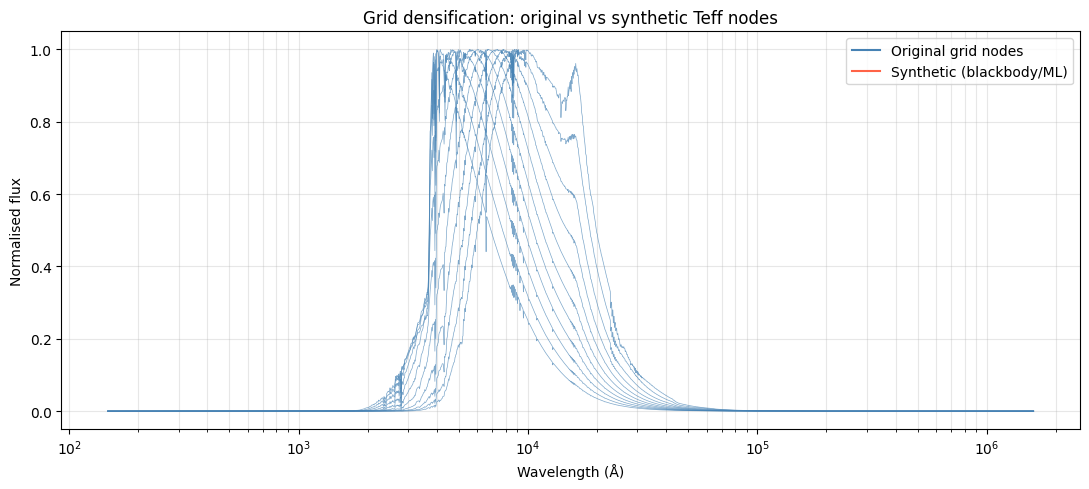

In [8]:
src_cube = FluxCube.from_file('../data/stellar_models/Kurucz2003/flux_cube.bin')
dst_cube = FluxCube.from_file('../data/stellar_models/Kurucz2003_dense/flux_cube.bin')

fig, ax = plt.subplots(figsize=(11, 5))
#
# # Plot every real node from the source at a fixed logg/meta slice
i_l, i_m = 0, 0
for i_t, t in enumerate(src_cube.teff_grid):
    fl = src_cube.flux[i_t, i_l, i_m, :]
    ax.plot(src_cube.wavelengths, fl / fl.max(), lw=0.5, color='steelblue', alpha=0.7)

# # Overlay the new synthetic nodes from the dense cube
orig_teffs = set(src_cube.teff_grid)
for i_t, t in enumerate(dst_cube.teff_grid):
    if t not in orig_teffs:
        fl = dst_cube.flux[i_t, i_l, i_m, :]
        ax.plot(dst_cube.wavelengths, fl / fl.max(), lw=0.5, color='tomato', alpha=0.5)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='steelblue', label='Original grid nodes'),
    Line2D([0], [0], color='tomato',    label='Synthetic (blackbody/ML)'),
])

ax.set_xscale('log')
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Normalised flux')
ax.set_title('Grid densification: original vs synthetic Teff nodes')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 4. Using the Dense Cube in MESA

The dense cube is a drop-in replacement. Copy `tmap_dense/flux_cube.bin` and the original `lookup_table.csv` into the MESA model directory. MESA's Hermite interpolator now operates over 1 000 K intervals instead of 9 000 K, eliminating the stair-stepping artefact in photometric light curves.

In [9]:
# Inspect the resulting dense grid
teff_dense, gaps_dense = inspect_teff_grid('../data/stellar_models/Kurucz2003_dense/flux_cube.bin')

Cube: ../data/stellar_models/Kurucz2003_dense/flux_cube.bin
  Teff: 3500 – 50000 K  (76 points)
  Teff gaps: min=250 K  max=1000 K  mean=620 K
  Grid: 76T × 11L × 8M × 1199W
